# Лабораторна робота №8.

## Виконав: П'ятибрат Д.С.

## Тема. Структура даних граф. Алгоритми на графах
## Мета
засвоїти представлення структури даних граф та основні
алгоритми роботи з ними засобами Python.


In [1]:
pip install networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
class Vertex:
    def __init__(self, key):
        self.id = key 
        self.connectedTo = {} 
    def addNeighbor(self, nbr, weight=0):
        self.connectedTo[nbr] = weight
    def getConnections(self):
        return self.connectedTo.keys()
    def getId(self):
        return self.id
    def getWeight(self, nbr):
        return self.connectedTo[nbr]

class Graph:
    def __init__(self):
        self.vertList = {}
        self.numVertices = 0
    def addVertex(self, key):
        self.numVertices += 1
        newVertex = Vertex(key)
        self.vertList[key] = newVertex
        return newVertex
    def addEdge(self, f, t, cost=0):
        if f not in self.vertList: self.addVertex(f)
        if t not in self.vertList: self.addVertex(t)
        self.vertList[f].addNeighbor(self.vertList[t], cost)
    def getVertices(self):
        return self.vertList.keys()
    def __iter__(self):
        return iter(self.vertList.values())

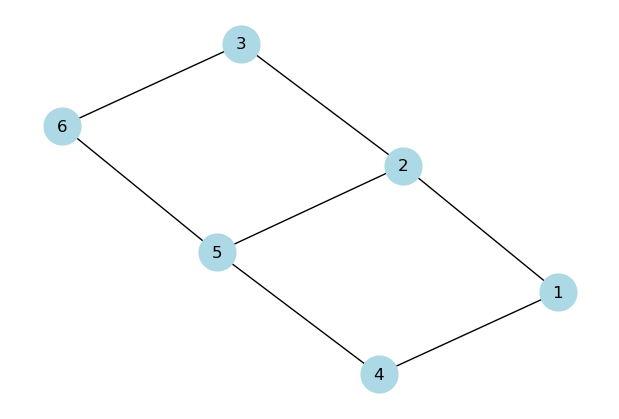

DFS результат: {1, 2, 3, 4, 5, 6}
BFS шляхи (1->6): [[1, 2, 3, 6], [1, 2, 5, 6], [1, 4, 5, 6], [1, 4, 5, 2, 3, 6]]
Дейкстра (відстані): {1: 0, 4: 2, 2: 5, 5: 5, 6: 6, 3: 12}


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Створення графа для візуалізації
G = nx.Graph()
G.add_edges_from([(1,2), (1,4), (2,3), (2,5), (3,6), (4,5), (5,6)])

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700)
plt.show()

# DFS
def dfs(graph, start, visited=None):
    if visited is None: visited = set()
    visited.add(start)
    for next_v in graph.neighbors(start):
        if next_v not in visited: dfs(graph, next_v, visited)
    return visited

# BFS
def bfs_paths(graph, start, goal):
    queue = [(start, [start])]
    while queue:
        (vertex, path) = queue.pop(0)
        for next_v in set(graph.neighbors(vertex)) - set(path):
            if next_v == goal: yield path + [next_v]
            else: queue.append((next_v, path + [next_v]))

# Виклик алгоритмів
print("DFS результат:", dfs(G, 1))
print("BFS шляхи (1->6):", list(bfs_paths(G, 1, 6)))

# Дейкстра
G_w = nx.Graph()
G_w.add_weighted_edges_from([(1,2,5), (1,4,2), (2,3,8), (2,5,4), (3,6,6), (4,5,3), (5,6,1)])
lengths, paths = nx.single_source_dijkstra(G_w, 1)
print("Дейкстра (відстані):", lengths)

### Контрольні питання

**1. Що таке граф у термінах теорії графів? Наведіть приклади реальних ситуацій.**
Граф — це сукупність вершин та ребер, що моделює зв’язки між об’єктами. Приклади: карти доріг, соцмережі, комп’ютерні мережі.

**2. Які основні види графів існують?**
Орієнтовані (напрямок важливий), неорієнтовані (зв'язок двосторонній), зважені (ребра мають вагу) та незважені.

**3. Як можна представити граф у пам’яті комп'ютера?**
Матриця суміжності ($N \times N$ таблиця) або список суміжності (словник вершин зі списками сусідів). Список суміжності ефективніший за пам'яттю для розріджених графів.

**4. Як працює алгоритм пошуку в ширину (BFS)?**
BFS обходить граф рівень за рівнем за допомогою черги. Застосовується для пошуку найкоротшого шляху в незважених графах.

**5. Що таке алгоритм пошуку в глибину (DFS)?**
DFS йде "вглиб" графа, досліджуючи кожну гілку до кінця перед поверненням назад, використовуючи рекурсію або стек. Застосовується для пошуку циклів.

**6. Опишіть алгоритм Дейкстри.**
Алгоритм знаходження найкоротшого шляху у зваженому графі від однієї вершини до всіх інших. Умова роботи: ваги ребер не можуть бути від'ємними.